In [1]:
# %%
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = "results"
FILE_PATTERNS = ["*_with_subject.csv", "*_with_subject"]  # por si algún archivo quedó sin .csv

# ---------- IO ----------
def _read_csv_safe(path: Path) -> pd.DataFrame:
    """Lee CSV con tolerancia a problemas de encoding."""
    for enc in [None, "utf-8", "latin-1"]:
        try:
            return pd.read_csv(path, encoding=None if enc is None else enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, engine="python")

def load_files_separately(results_dir: str = RESULTS_DIR,
                          patterns = FILE_PATTERNS) -> dict:
    """
    Carga TODOS los CSV que terminan en `_with_subject` desde results_dir,
    y retorna un dict: { filename: DataFrame }
    """
    d = Path(results_dir)
    files = []
    for pat in patterns:
        files.extend(sorted(d.glob(pat)))
    if not files:
        raise FileNotFoundError(f"No se encontraron CSVs en '{results_dir}' que terminen con '_with_subject'.")
    out = {}
    for f in files:
        df = _read_csv_safe(f)
        df["__source_file"] = f.name
        out[f.name] = df
    return out

# ---------- Normalización y flags ----------
def normalize_result(val):
    """
    Normaliza 'result' a:
      - 'Hit'
      - 'Miss'
      - 'Miss (no <answer>)'
    """
    if pd.isna(val):
        return None
    s = str(val).strip()
    sl = s.lower()
    if sl.startswith("hit"):
        return "Hit"
    if sl.startswith("miss"):
        if "no <answer>" in sl:
            return "Miss (no <answer>)"
        return "Miss"
    return s  # deja otros valores tal cual

def add_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega:
      - result_norm (Hit / Miss / Miss (no <answer>))
      - is_correct (True si Hit; si falta 'result', usa predicted==gold)
      - is_no_answer (True si Miss (no <answer>))
      - coherence_num (numérico)
      - subject como str
    """
    df = df.copy()

    # result_norm
    if "result" in df.columns:
        df["result_norm"] = df["result"].apply(normalize_result)
    else:
        df["result_norm"] = None

    # is_correct
    if df["result_norm"].notna().any():
        df["is_correct"] = df["result_norm"].eq("Hit")
    else:
        df["is_correct"] = df["predicted_answer"].astype(str) == df["gold_answer"].astype(str)

    # is_no_answer
    df["is_no_answer"] = df["result_norm"].eq("Miss (no <answer>)")

    # subject y coherence num
    if "subject" in df.columns:
        df["subject"] = df["subject"].astype(str)
    df["coherence_num"] = pd.to_numeric(df.get("coherence", np.nan), errors="coerce")

    # Validaciones mínimas
    required = {"predicted_answer", "gold_answer", "subject", "steering_method"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    return df

# ---------- Métricas ----------
def compute_metrics_by(df: pd.DataFrame, group_cols=None):
    """
    Si group_cols es None o [], devuelve accuracy total.
    Si group_cols tiene columnas, devuelve accuracy y n agrupado por esas columnas.
    """
    base = df.copy()
    if not group_cols:
        return pd.DataFrame({"accuracy":[base["is_correct"].mean()], "n":[len(base)]})
    out = (base.groupby(group_cols, dropna=False)["is_correct"]
                .agg(["mean","count"])
                .rename(columns={"mean":"accuracy","count":"n"})
                .reset_index())
    return out

# ---------- Plot ----------
def plot_accuracy_bars(group_df: pd.DataFrame, group_cols, title: str):
    """
    Grafica accuracy (%) de group_df donde group_df = compute_metrics_by(..., group_cols).
    """
    if group_df.empty:
        print("No hay datos para graficar.")
        return
    tmp = group_df.copy()
    tmp["accuracy"] = (tmp["accuracy"] * 100).astype(float)
    # etiqueta combinada
    if group_cols:
        tmp["__label"] = tmp[group_cols].astype(str).agg(" | ".join, axis=1)
    else:
        tmp["__label"] = ["GLOBAL"]
    tmp = tmp.sort_values("accuracy", ascending=False)

    plt.figure()
    plt.bar(tmp["__label"], tmp["accuracy"])
    plt.ylabel("Accuracy (%)")
    plt.xlabel(" | ".join(group_cols) if group_cols else "Global")
    plt.title(title)
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [2]:
# %%
files_dict = load_files_separately("results")

# Agregar flags y validar columnas para CADA archivo
for fname in list(files_dict.keys()):
    files_dict[fname] = add_flags(files_dict[fname])

print(f"Archivos cargados: {len(files_dict)}")
for fname in files_dict:
    print(" -", fname, "->", len(files_dict[fname]), "filas")

Archivos cargados: 1
 - eval_gpt-4o-mini_var_Meta-Llama-3.1-8B-Instruct_dt_20250929_1201_answers_with_subject.csv -> 9572 filas


In [ ]:
# %%
import ipywidgets as W
from IPython.display import clear_output

# Construcción de controles
file_dd = W.Dropdown(options=sorted(files_dict.keys()), description="Archivo:", layout=W.Layout(width="400px"))

# Estos se llenan dinámicamente según archivo
method_ms = W.SelectMultiple(options=[], description="Method", layout=W.Layout(width="300px", height="140px"))
subject_ms = W.SelectMultiple(options=[], description="Subject", layout=W.Layout(width="300px", height="140px"))
query_ms   = W.SelectMultiple(options=[], description="Query",   layout=W.Layout(width="300px", height="140px"))

# Group by toggles
gb_method  = W.Checkbox(value=True , description="Agrupar por Method")
gb_subject = W.Checkbox(value=False, description="Agrupar por Subject")
gb_query   = W.Checkbox(value=False, description="Agrupar por Query")

btn_run = W.Button(description="Actualizar", button_style="primary")
out = W.Output()

def _update_filter_options(change=None):
    df0 = files_dict[file_dd.value]
    method_vals = sorted([x for x in df0["steering_method"].dropna().unique()])
    subject_vals = sorted([x for x in df0["subject"].dropna().unique()])
    query_vals = sorted([x for x in df0["query"].dropna().unique()]) if "query" in df0.columns else []

    method_ms.options = method_vals
    method_ms.value   = tuple(method_vals)  # todos por defecto

    subject_ms.options = subject_vals
    subject_ms.value   = tuple(subject_vals)

    query_ms.options = query_vals
    query_ms.value   = tuple(query_vals)

def _apply_filters(df, methods_sel, subjects_sel, queries_sel):
    g = df.copy()
    if methods_sel:
        g = g[g["steering_method"].isin(methods_sel)]
    if subjects_sel:
        g = g[g["subject"].isin(subjects_sel)]
    if "query" in g.columns and queries_sel:
        g = g[g["query"].isin(queries_sel)]
    return g

def _selected_group_cols(df):
    cols = []
    if gb_method.value:
        cols.append("steering_method")
    if gb_subject.value:
        cols.append("subject")
    if gb_query.value and "query" in df.columns:
        cols.append("query")
    return cols

@out.capture(clear_output=True)
def _on_run_clicked(b):
    df0 = files_dict[file_dd.value]
    df_filtered = _apply_filters(df0, list(method_ms.value), list(subject_ms.value), list(query_ms.value) if "query" in df0.columns else [])

    group_cols = _selected_group_cols(df_filtered)
    res = compute_metrics_by(df_filtered, group_cols=group_cols if group_cols else None)

    # Vista
    res_view = res.copy()
    res_view["accuracy"] = (res_view["accuracy"] * 100).round(2)
    print("=== Resultados ===")
    display(res_view.sort_values("accuracy", ascending=False if group_cols else True))

    # Plot
    title = (f"{file_dd.value} — Accuracy " + (("por " + " + ".join(group_cols)) if group_cols else "(GLOBAL)"))
    plot_accuracy_bars(res, group_cols, title=title)

file_dd.observe(_update_filter_options, names="value")
btn_run.on_click(_on_run_clicked)

# Inicializar opciones según archivo por defecto
_update_filter_options()

ui = W.VBox([
    file_dd,
    W.HBox([method_ms, subject_ms, query_ms]),
    W.HBox([gb_method, gb_subject, gb_query]),
    btn_run,
    out
])
display(ui)

=== Frecuencia de SUBJECT en datasets/mmlu.json ===


,subject,count
0,abstract_algebra,5
1,high_school_statistics,5
2,high_school_world_history,5
3,human_aging,5
4,human_sexuality,5
5,international_law,5
6,jurisprudence,5
7,logical_fallacies,5
8,machine_learning,5
9,management,5


TOTAL=285


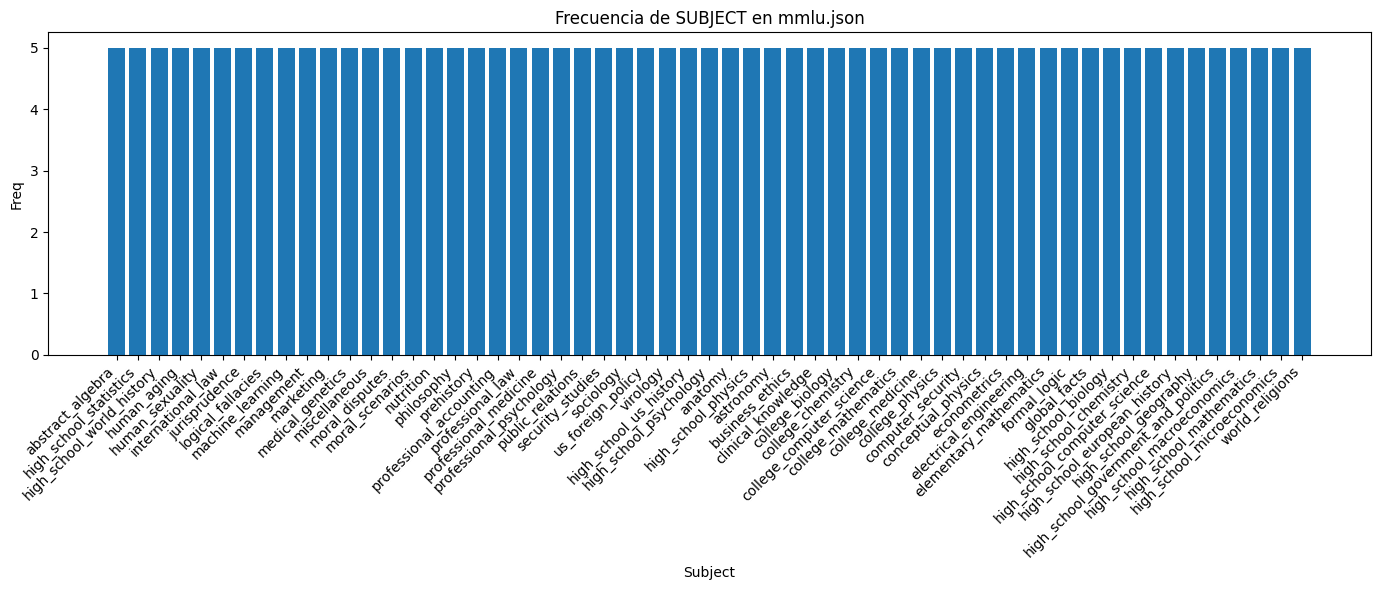

In [4]:
# %%
import json

mmlu_path = Path("datasets/mmlu.json")
if not mmlu_path.exists():
    print("No se encontró datasets/mmlu.json")
else:
    with mmlu_path.open("r", encoding="utf-8") as f:
        mmlu = json.load(f)

    subjects = mmlu.get("subject", [])
    sub_ser = pd.Series(subjects, name="subject")
    freq = sub_ser.value_counts().rename_axis("subject").reset_index(name="count")

    print("=== Frecuencia de SUBJECT en datasets/mmlu.json ===")
    display(freq)

    print(f"TOTAL={sum(freq['count'])}")

    plt.figure(figsize=(14, 6))
    plt.bar(freq["subject"], freq["count"])
    plt.title("Frecuencia de SUBJECT en mmlu.json")
    plt.xlabel("Subject")
    plt.ylabel("Freq")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()